In [2]:
from google.colab import files
uploaded = files.upload()

Saving placement_predict_50k_Dataset.csv to placement_predict_50k_Dataset.csv


[Batch GD] Test RMSE = 5.0696

Saved loss curve to loss_curve.png

=== RMSE Comparison ===
Method                 Test RMSE
Batch GD                  5.0696
Mini-batch GD             5.0689
sklearn LinearReg         5.0695


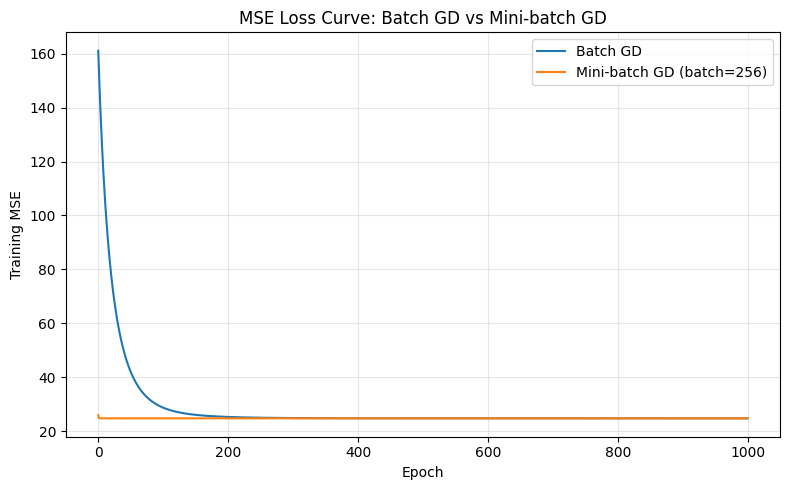

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

df = pd.read_csv("placement_predict_50k_Dataset.csv")

# Available DataFrame columns: ['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']

# Selecting relevant numerical features based on the dataset columns and common sense for a placement prediction
FEATURES = ['CGPA', 'AptitudeTestScore', 'CodingTestScore']
TARGET = "Salary Package"

data = df[FEATURES + [TARGET]].copy()
data[FEATURES] = data[FEATURES].fillna(data[FEATURES].median())

X = data[FEATURES].values
y = data[TARGET].values.reshape(-1, 1)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features using StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Add bias term to X (for intercept in linear regression)
n_samples, n_features = X_train_s.shape
X_train_b = np.hstack([np.ones((n_samples, 1)), X_train_s])
X_test_b = np.hstack([np.ones((X_test_s.shape[0], 1)), X_test_s])

def compute_mse(X, y, theta):
    """Computes the Mean Squared Error."""
    preds = X @ theta
    errors = preds - y
    return np.mean(errors ** 2)

def batch_gradient_descent(X, y, theta_initial, lr, n_epochs):
    """Performs Batch Gradient Descent."""
    m = X.shape[0]
    theta = theta_initial.copy()
    loss_history = []

    for epoch in range(n_epochs):
        preds = X @ theta
        errors = preds - y
        gradient = (2 / m) * (X.T @ errors)
        theta -= lr * gradient
        loss_history.append(compute_mse(X, y, theta))
    return theta, loss_history

def mini_batch_gradient_descent(X, y, theta_initial, lr, n_epochs, batch_size, seed=42):
    """Performs Mini-batch Gradient Descent."""
    m = X.shape[0]
    theta = theta_initial.copy()
    loss_history = []
    rng = np.random.default_rng(seed)

    for epoch in range(n_epochs):
        # Shuffle the data for each epoch
        indices = rng.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            start = i
            end = min(i + batch_size, m)
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            preds = X_batch @ theta
            errors = preds - y_batch
            gradient = (2 / X_batch.shape[0]) * (X_batch.T @ errors) # Use batch size for gradient
            theta -= lr * gradient

        # Record loss after each epoch using the full training set
        loss_history.append(compute_mse(X, y, theta))
    return theta, loss_history

# --- Hyperparameters for Gradient Descent ---
learning_rate = 0.01
n_epochs = 1000
initial_theta = np.zeros((X_train_b.shape[1], 1))

# Run Batch Gradient Descent
theta_gd, loss_history_gd = batch_gradient_descent(X_train_b, y_train, initial_theta, learning_rate, n_epochs)
rmse_gd = np.sqrt(compute_mse(X_test_b, y_test, theta_gd))
print(f"[Batch GD] Test RMSE = {rmse_gd:.4f}")

# Scikit-learn Linear Regression for comparison
sk_model = LinearRegression()
sk_model.fit(X_train_s, y_train)
y_pred_sk = sk_model.predict(X_test_s)
rmse_sklearn = np.sqrt(mean_squared_error(y_test, y_pred_sk))

# Run Mini-batch Gradient Descent
batch_size = 256
theta_mb, loss_history_mb = mini_batch_gradient_descent(X_train_b, y_train, initial_theta, learning_rate, n_epochs, batch_size)
rmse_mb = np.sqrt(compute_mse(X_test_b, y_test, theta_mb))

plt.figure(figsize=(8, 5))
plt.plot(loss_history_gd, label="Batch GD")
plt.plot(loss_history_mb, label=f"Mini-batch GD (batch={batch_size})")
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("MSE Loss Curve: Batch GD vs Mini-batch GD")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
print("\nSaved loss curve to loss_curve.png")

print("\n=== RMSE Comparison ===")
print(f"{'Method':<20}{'Test RMSE':>12}")
print(f"{'Batch GD':<20}{rmse_gd:>12.4f}")
print(f"{'Mini-batch GD':<20}{rmse_mb:>12.4f}")
print(f"{'sklearn LinearReg':<20}{rmse_sklearn:>12.4f}")